# 📊 SCGI Analysis — School Capacity Gap Index

---

## Definisi SCGI

**School Capacity Gap Index (SCGI)** adalah indeks komposit yang mengukur urgensi
intervensi kapasitas pendidikan di suatu kecamatan, dihitung pada skala 0–100.

$$\text{SCGI} = 0.50 \times \text{DeficitRate} + 0.30 \times \text{UtilisasiNorm} + 0.20 \times \text{GrowthRate}$$

| Komponen | Formula | Bobot |
|---|---|---|
| **Deficit Rate** | $\max(0, \frac{\text{Demand}_{2030} - \text{Kapasitas}}{\text{Demand}_{2030}})$ | 50% |
| **Utilisasi Norm** | $\min(\frac{\text{Utilisasi}_{2030}}{200\%}, 1)$ | 30% |
| **Growth Rate** | $\min(\max(0, \frac{\text{Demand}_{2030} - \text{Demand}_{2025}}{\text{Demand}_{2025}}), 1)$ | 20% |

### Kategori SCGI

| Skor | Kategori | Interpretasi |
|---|---|---|
| ≥ 70 | 🔴 **KRITIS** | Intervensi mendesak — USB diprioritaskan |
| ≥ 50 | 🟠 **TINGGI** | Perencanaan segera — USB/RKB perlu dijadwalkan |
| ≥ 30 | 🟡 **SEDANG** | Monitoring ketat — RKB mungkin diperlukan |
| >  0 | 🟢 **RENDAH** | Relatif aman — pantau pertumbuhan |
| ≤  0 | ✅ **AMAN** | Kapasitas mencukupi |

**Referensi desain**: Wang & Wang (2020), *A Composite Index for School Infrastructure Needs Assessment*, Journal of Educational Planning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
DATA = '../medallion/exports/'

scgi = pd.read_csv(DATA + 'scgi.csv')
scgi = scgi.sort_values('scgi_rank')

CATEGORY_COLORS = {
    'KRITIS':  '#d62728',
    'TINGGI':  '#ff7f0e',
    'SEDANG':  '#bcbd22',
    'RENDAH':  '#2ca02c',
    'AMAN':    '#1f77b4',
}

print(f'Data shape: {scgi.shape}')
scgi[['kecamatan_norm','scgi_score','scgi_category','deficit_rate','utilisasi_norm','growth_rate']].head(10)

Data shape: (31, 15)


,kecamatan_norm,scgi_score,scgi_category,deficit_rate,utilisasi_norm,growth_rate
0,PABEAN CANTIAN,55.37,TINGGI,0.507446,1.0000,0.00000
1,SAWAHAN,38.65,SEDANG,0.327199,0.7430,0.00000
2,TAMBAKSARI,37.61,SEDANG,0.314504,0.7295,0.00000
3,ASEMROWO,37.41,SEDANG,0.307313,0.7220,0.01933
4,SIMOKERTO,36.09,SEDANG,0.295797,0.7100,0.00000
5,BUBUTAN,33.44,SEDANG,0.262214,0.6775,0.00000
6,GUNUNG ANYAR,32.93,SEDANG,0.255662,0.6715,0.00000
7,SEMAMPIR,31.43,SEDANG,0.235998,0.6545,0.00000
8,WIYUNG,29.32,RENDAH,0.207812,0.6310,0.00000
9,TEGALSARI,28.07,RENDAH,0.190639,0.6180,0.00000


## 1. Ranking SCGI Seluruh Kecamatan

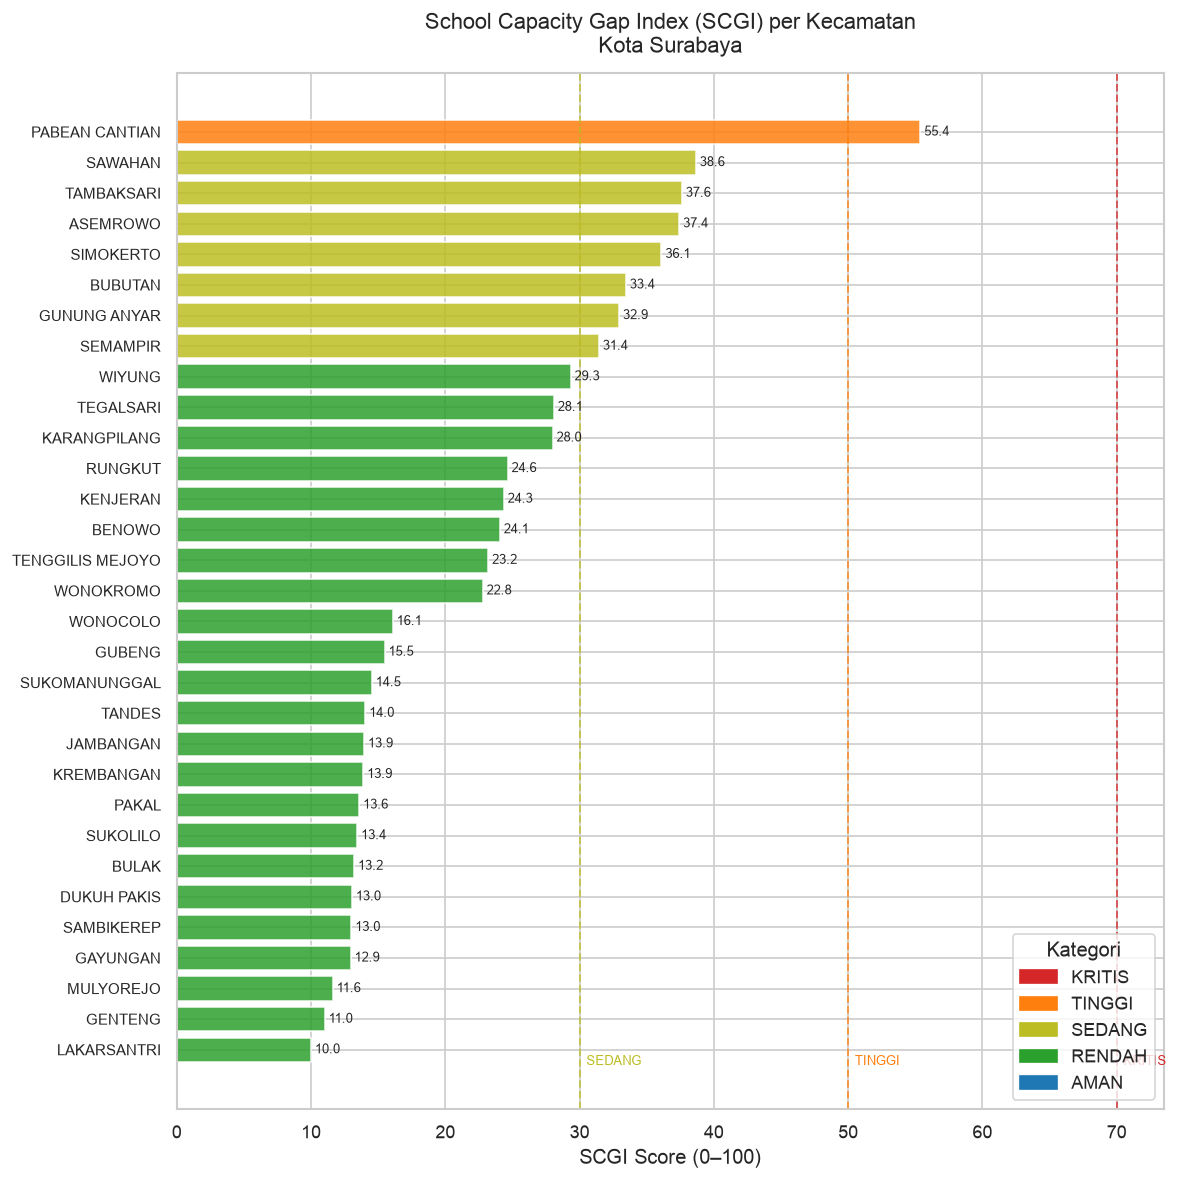

In [2]:
fig, ax = plt.subplots(figsize=(10, 10))
colors  = [CATEGORY_COLORS[c] for c in scgi['scgi_category']]
bars = ax.barh(range(len(scgi)), scgi['scgi_score'], color=colors, alpha=0.85, edgecolor='white')

ax.set_yticks(range(len(scgi)))
ax.set_yticklabels(scgi['kecamatan_norm'], fontsize=9)
ax.set_xlabel('SCGI Score (0–100)')
ax.set_title('School Capacity Gap Index (SCGI) per Kecamatan\nKota Surabaya', pad=12)
ax.invert_yaxis()

# Threshold lines
for threshold, label, color in [(70,'KRITIS','#d62728'),(50,'TINGGI','#ff7f0e'),
                                  (30,'SEDANG','#bcbd22')]:
    ax.axvline(threshold, color=color, ls='--', lw=1.2, alpha=0.7)
    ax.text(threshold+0.5, len(scgi)-0.5, label, color=color, fontsize=8)

# Score labels
for bar, val in zip(bars, scgi['scgi_score']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=8)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in CATEGORY_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', title='Kategori')

plt.tight_layout()
plt.show()

## 2. Distribusi Kategori & Statistik

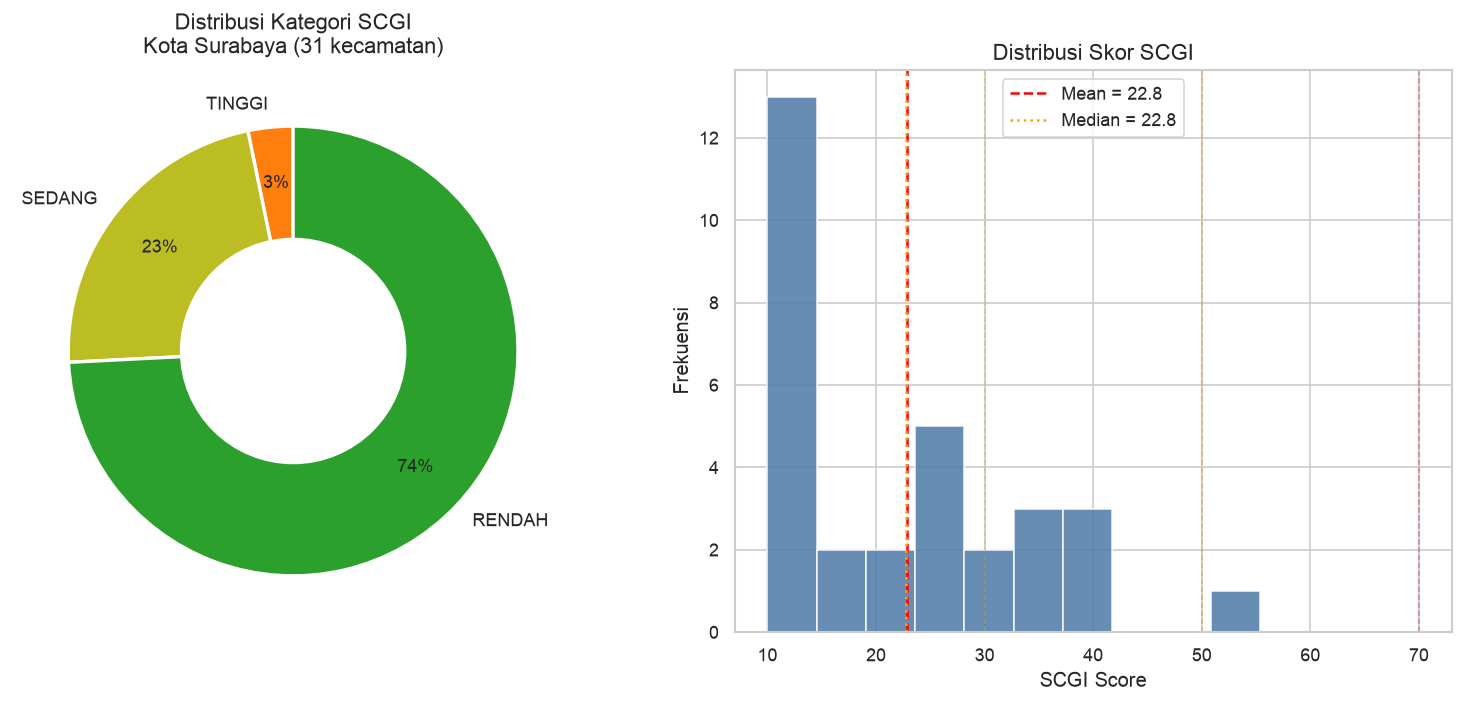


Statistik per Kategori:


,n_kecamatan,scgi_mean,scgi_min,scgi_max
scgi_category,,,,
RENDAH,23,17.57,9.99,29.32
SEDANG,7,35.37,31.43,38.65
TINGGI,1,55.37,55.37,55.37


In [3]:
cat_counts = scgi['scgi_category'].value_counts()
cat_order  = ['KRITIS','TINGGI','SEDANG','RENDAH','AMAN']
cat_counts = cat_counts.reindex(cat_order).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Donut chart
ax1 = axes[0]
colors_pie = [CATEGORY_COLORS[c] for c in cat_counts.index]
wedges, texts, autotexts = ax1.pie(
    cat_counts.values, labels=cat_counts.index, autopct='%1.0f%%',
    colors=colors_pie, startangle=90, pctdistance=0.75,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'})
centre_circle = plt.Circle((0,0), 0.50, fc='white')
ax1.add_artist(centre_circle)
ax1.set_title('Distribusi Kategori SCGI\nKota Surabaya (31 kecamatan)', pad=10)
for at in autotexts: at.set_fontsize(11)

# SCGI histogram
ax2 = axes[1]
ax2.hist(scgi['scgi_score'], bins=10, color='#4E79A7', edgecolor='white', alpha=0.85)
ax2.axvline(scgi['scgi_score'].mean(), color='red', ls='--', lw=1.5,
             label=f'Mean = {scgi["scgi_score"].mean():.1f}')
ax2.axvline(scgi['scgi_score'].median(), color='orange', ls=':', lw=1.5,
             label=f'Median = {scgi["scgi_score"].median():.1f}')
for t, c in [(70,'#d62728'),(50,'#ff7f0e'),(30,'#bcbd22')]:
    ax2.axvline(t, color=c, ls='--', lw=0.9, alpha=0.5)
ax2.set_xlabel('SCGI Score')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Distribusi Skor SCGI')
ax2.legend()

plt.tight_layout()
plt.show()

# Category statistics
cat_stats = scgi.groupby('scgi_category')['scgi_score'].agg(['count','mean','min','max'])
cat_stats.columns = ['n_kecamatan','scgi_mean','scgi_min','scgi_max']
print('\nStatistik per Kategori:')
cat_stats.round(2)

## 3. Breakdown Komponen SCGI (Stacked Bar)

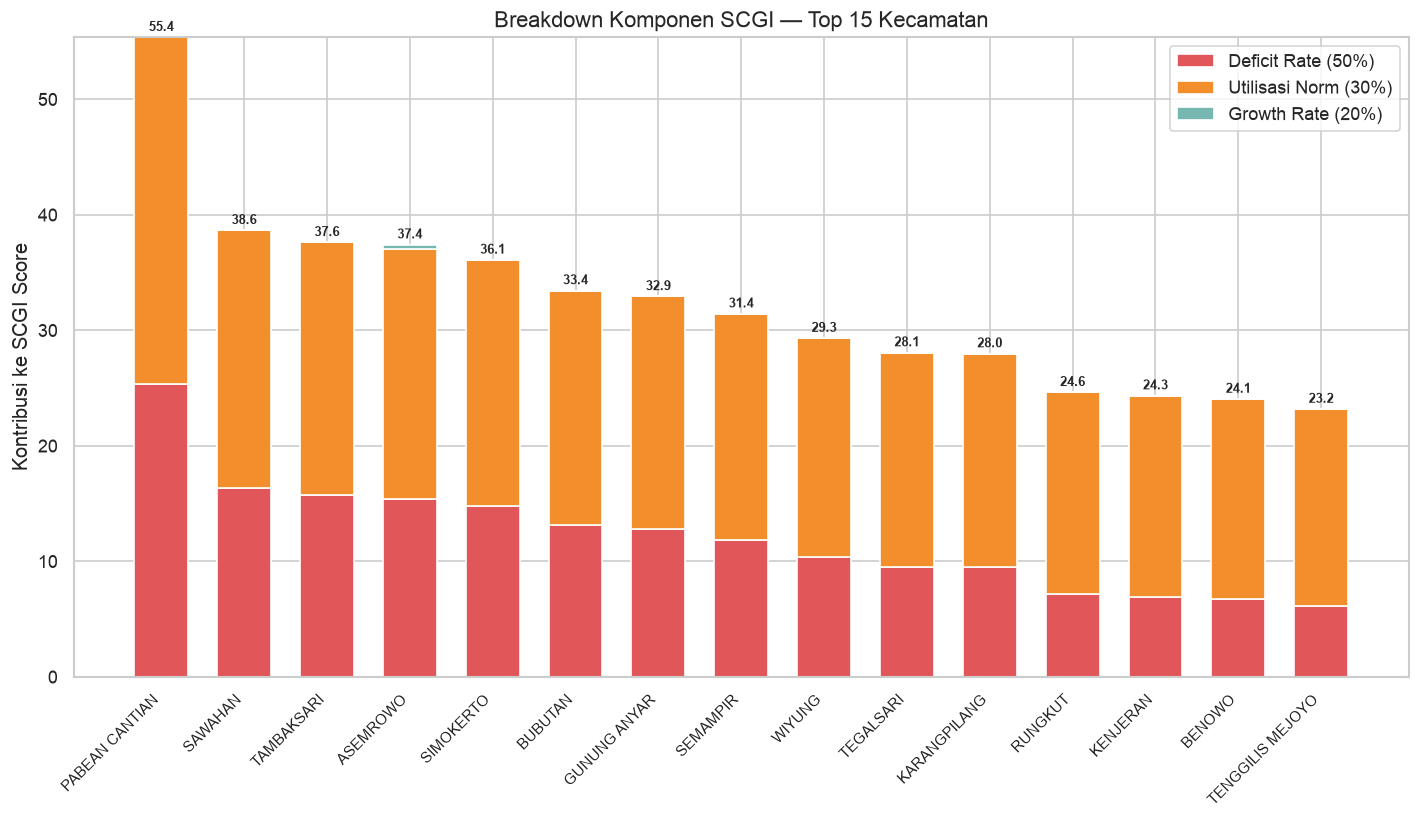

In [4]:
top15 = scgi.head(15).copy()
top15['deficit_contrib']    = top15['deficit_rate']   * 0.50 * 100
top15['utilisasi_contrib']  = top15['utilisasi_norm'] * 0.30 * 100
top15['growth_contrib']     = top15['growth_rate']    * 0.20 * 100

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(top15))
w = 0.65

b1 = ax.bar(x, top15['deficit_contrib'],   w, label='Deficit Rate (50%)',   color='#E15759')
b2 = ax.bar(x, top15['utilisasi_contrib'], w, label='Utilisasi Norm (30%)', color='#F28E2B',
             bottom=top15['deficit_contrib'])
b3 = ax.bar(x, top15['growth_contrib'],    w, label='Growth Rate (20%)',    color='#76B7B2',
             bottom=top15['deficit_contrib'] + top15['utilisasi_contrib'])

ax.set_xticks(x)
ax.set_xticklabels(top15['kecamatan_norm'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Kontribusi ke SCGI Score')
ax.set_title('Breakdown Komponen SCGI — Top 15 Kecamatan')
ax.legend()

# Add total score on top
for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(i, row['scgi_score']+0.3, f"{row['scgi_score']:.1f}",
            ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Scatter: Deficit Rate vs Utilisasi (coloured by SCGI)

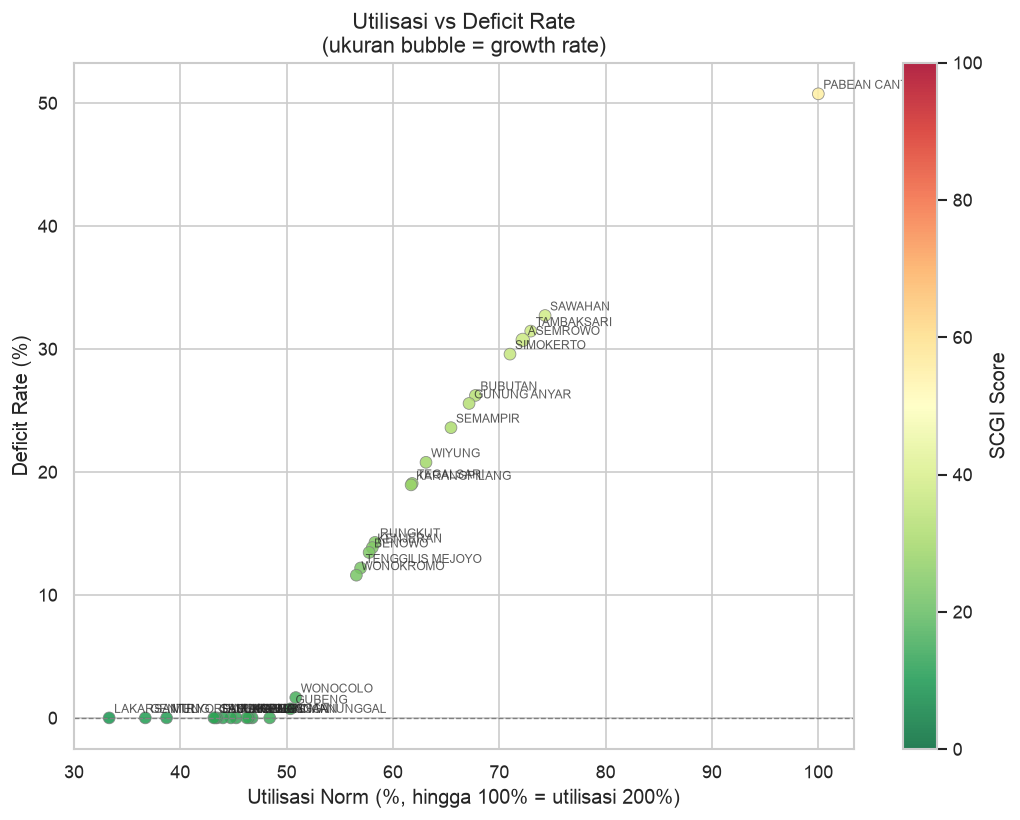

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(scgi['utilisasi_norm']*100, scgi['deficit_rate']*100,
                 c=scgi['scgi_score'], cmap='RdYlGn_r', s=scgi['growth_rate']*800+50,
                 alpha=0.85, edgecolors='grey', lw=0.5, vmin=0, vmax=100)
plt.colorbar(sc, label='SCGI Score')

for _, row in scgi.iterrows():
    ax.annotate(row['kecamatan_norm'],
                (row['utilisasi_norm']*100, row['deficit_rate']*100),
                fontsize=7, alpha=0.75, xytext=(3,3), textcoords='offset points')

ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Utilisasi Norm (%, hingga 100% = utilisasi 200%)')
ax.set_ylabel('Deficit Rate (%)')
ax.set_title('Utilisasi vs Deficit Rate\n(ukuran bubble = growth rate)')

plt.tight_layout()
plt.show()

---
## 📌 Kesimpulan SCGI

SCGI memberikan satu angka komposit yang mencerminkan urgency intervensi per kecamatan:
- **Deficit Rate** (bobot 50%) mengukur proporsi demand yang tidak dapat dilayani — komponen terbesar
- **Utilisasi Norm** (bobot 30%) mengukur seberapa penuh sekolah yang ada
- **Growth Rate** (bobot 20%) mengukur tekanan pertumbuhan ke depan

Kecamatan dengan SCGI tinggi adalah prioritas utama untuk pembangunan sekolah baru (USB) atau penambahan ruang kelas (RKB).